In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import re
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
import math

from common import (
    get_dataset_sort_key,
    INDEX_ORDER,
    index_colors,
    index_hatches,
    format_dataset_label,
    apply_style,
    save_fig,
    DATASET_PROPS,
    PLOT_DPI,
    LABEL_FONTSIZE,
    TICK_FONTSIZE,
    X_TICK_FONTSIZE,
    BAR_LABEL_FONTSIZE,
    FONT_COLOR,
    TICK_FONTS_COLOR,
    BAR_TEXT_COLOR,
)

# ---------------------------------------------------------------------------
# 1. Manually collected index size data (in bytes)
# ---------------------------------------------------------------------------
# VSS (v1.4.4): CALL pragma_hnsw_index_info(); Default: ef_construction = 128, M = 16, M0 = 32.
# pgvector (see docker-compose.yml): https://github.com/pgvector/pgvector/issues/276
# - psql -h localhost -p 5432 -U postgres vectordb -c "SELECT pg_relation_size('pgvector_index');"
# - HNSW: --m 16 --ef-construction 128
# - IVFFlat: --lists (see PGVECTOR_IVFFLAT_LISTS in utils.py)
# PDX (9df687b): CALL pdxearch_index_info();

# Structure: dataset_name → index_type → size in bytes
# Datasets match the case names used in index_creation.ipynb
data = {
    "Cohere (1M × 768)": {
        "DuckDB VSS (HNSW)":                          4558821312,
        "pgvector (HNSW)":                             4095680512,
        "pgvector (IVFFlat)":                          4102119424,
        "DuckDB PDXearch (IVF, Global, F32)":          3087096192,
        "DuckDB PDXearch (IVF, Global, U8)":           783096208,
        "DuckDB PDXearch (IVF, Row Group, F32)":       3098223376,
        "DuckDB PDXearch (IVF, Row Group, U8)":        794223520,
    },
    "OpenAI (500K × 1536)": {
        "DuckDB VSS (HNSW)":                          4420603648,
        "pgvector (HNSW)":                             4096008192,
        "pgvector (IVFFlat)":                          4100104192,
        "DuckDB PDXearch (IVF, Global, F32)":          3081084192,
        "DuckDB PDXearch (IVF, Global, U8)":           777084208,
        "DuckDB PDXearch (IVF, Row Group, F32)":       3093719152,
        "DuckDB PDXearch (IVF, Row Group, U8)":        789719232,
    },
    "Agnews (769K × 1024)": {
        "DuckDB VSS (HNSW)":                          4556976368,
        "pgvector (HNSW)":                             6256967680,
        "pgvector (IVFFlat)":                          6309093376,
        "DuckDB PDXearch (IVF, Global, F32)":          3163793848,
        "DuckDB PDXearch (IVF, Global, U8)":           800252360,
        "DuckDB PDXearch (IVF, Row Group, F32)":       3175191704,
        "DuckDB PDXearch (IVF, Row Group, U8)":        811650312,
    },
    "SIFT (4999K × 128)": {
        "DuckDB VSS (HNSW)":                          5396119552,
        "pgvector (HNSW)":                             4159668224,
        "pgvector (IVFFlat)":                          2739937280,
        "DuckDB PDXearch (IVF, Global, F32)":          2620674688,
        "DuckDB PDXearch (IVF, Global, U8)":           701058704,
        "DuckDB PDXearch (IVF, Row Group, F32)":       2630342768,
        "DuckDB PDXearch (IVF, Row Group, U8)":        710727424,
    },
    "ArxivForFanns (1.2M × 1024)": {
        "DuckDB VSS (HNSW)":                          8855388608,
        "pgvector (HNSW)":                             9826623488,
        "pgvector (IVFFlat)":                          9839386624,
        "DuckDB PDXearch (IVF, Global, F32)":          4934115712,
        "DuckDB PDXearch (IVF, Global, U8)":           1247715728,
        "DuckDB PDXearch (IVF, Row Group, F32)":       4949607832,
        "DuckDB PDXearch (IVF, Row Group, U8)":        1263207992,
    },
}

def format_bytes(n: float, precision_is_zero: bool = False) -> str:
    """Format a byte count as a human-readable string."""
    if abs(n) < 1024:
        return f"{n:.0f} B"
    for unit in ('KiB', 'MiB', 'GiB', 'TiB'):
        n /= 1024
        if abs(n) < 1024:
            if precision_is_zero:
                return f"{n:.0f} {unit}"
            else:
                return f"{n:.2f} {unit}"
    if precision_is_zero:
        return f"{n:.0f} PiB"
    else:
        return f"{n:.2f} PiB"

In [2]:
# ---------------------------------------------------------------------------
# 2. Dataset ordering
# ---------------------------------------------------------------------------

datasets = sorted(data.keys(), key=get_dataset_sort_key)

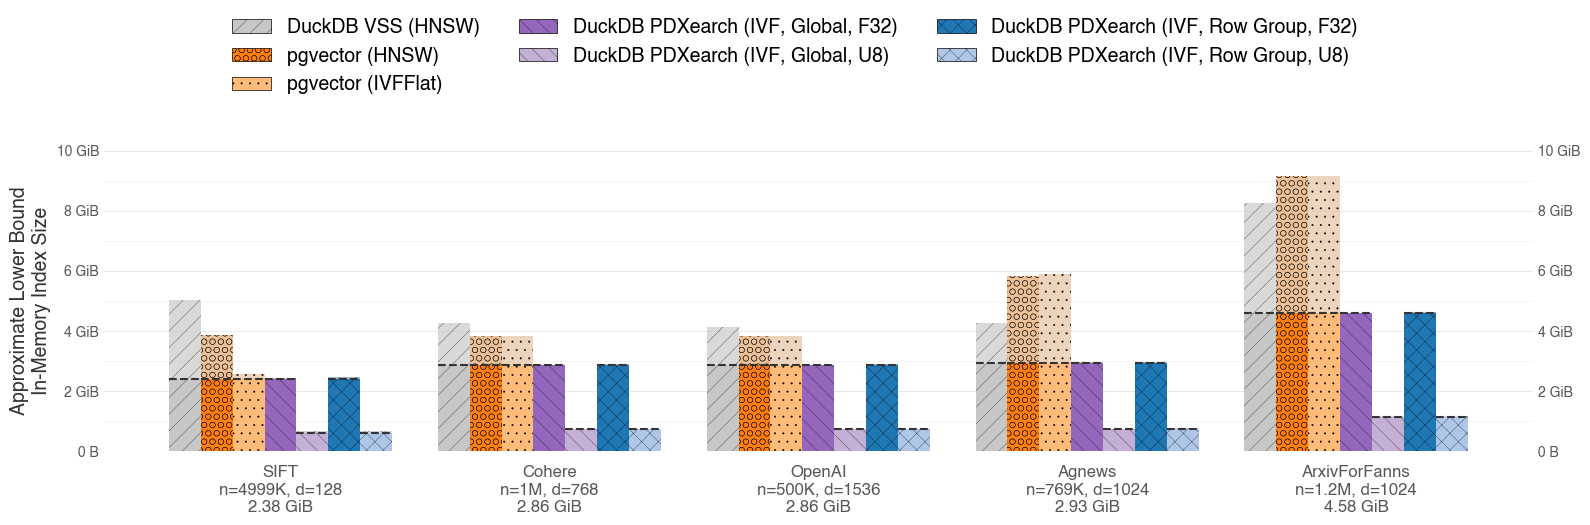

In [3]:
# ---------------------------------------------------------------------------
# 3. Bar plot: absolute index size (labels show overhead and total)
# ---------------------------------------------------------------------------

apply_style()

# Reference line styling (dashed line at embeddings baseline)
REF_F32_COLOR = '#333333'
REF_U8_COLOR  = '#333333'

# Which raw baseline to use for the embeddings segment (F32 vs U8).
# F32 indexes are compared against raw F32, U8 indexes against raw U8.
INDEX_BASELINE = {
    "DuckDB VSS (HNSW)":                          "f32",
    "pgvector (HNSW)":                             "f32",
    "pgvector (IVFFlat)":                          "f32",
    "DuckDB PDXearch (IVF, Global, F32)":          "f32",
    "DuckDB PDXearch (IVF, Global, U8)":           "u8",
    "DuckDB PDXearch (IVF, Row Group, F32)":       "f32",
    "DuckDB PDXearch (IVF, Row Group, U8)":        "u8",
}

# Determine which index types are actually present (non-None values)
all_index_types = []
for idx in INDEX_ORDER:
    for ds in datasets:
        if data[ds].get(idx) is not None:
            all_index_types.append(idx)
            break
n_index_types = len(all_index_types)

bar_width = 0.35 # 0.7
group_width = n_index_types * bar_width + 0.2
group_spacing = 0.3

from matplotlib.ticker import FuncFormatter, AutoMinorLocator
from matplotlib.colors import to_rgb

def lower_contrast_color(color, gray=0.6, blend=0.5):
    """Return a lower-contrast (more muted) version by blending with gray."""
    rgb = to_rgb(color)
    return tuple((1 - blend) * gray + blend * c for c in rgb)

def bytes_formatter(val, pos):
    return format_bytes(val, precision_is_zero=True)

fig, ax1 = plt.subplots(1, 1, figsize=(16, 5)) # 25, 5

def draw_bars(ax, value_fn, ylabel, show_label=False):
    """Draw grouped bars on ax. value_fn(dataset, index_type, raw_f32, raw_u8) → float or None."""
    x_base = 0
    x_labels = []
    group_centers = []
    for dataset in datasets:
        group_start = x_base
        has_data = False

        props = DATASET_PROPS.get(dataset, {})
        n_emb = props.get("n", 0)
        dim   = props.get("d", 0)
        raw_f32 = n_emb * dim * 4
        raw_u8  = n_emb * dim * 1

        for idx_idx, index_type in enumerate(all_index_types):
            val = value_fn(dataset, index_type, raw_f32, raw_u8)
            if val is None:
                continue
            has_data = True
            x = group_start + idx_idx * bar_width
            baseline = raw_f32 if INDEX_BASELINE.get(index_type, "f32") == "f32" else raw_u8
            overhead = val - baseline
            color = index_colors.get(index_type, "#808080")
            color_muted = lower_contrast_color(color, gray=0.8, blend=0.5)
            hatch = index_hatches.get(index_type, "")

            # Stacked bar: bottom = embeddings (full color), top = overhead (muted)
            ax.bar(x, baseline, bar_width, color=color, hatch=hatch, label="")
            ax.bar(x, overhead, bar_width, bottom=baseline, color=color_muted, hatch=hatch,
                   alpha=0.70, label=index_type if dataset == datasets[0] else "")

            offset = max(1, abs(val) * 0.03)
            if show_label:
                label_text = f"{format_bytes(overhead)}\n({format_bytes(val)})"
            else:
                label_text = None
            x_text = x  # bar right edge (bar is centered at x)
            ax.text(x_text, val + offset, label_text,
                    ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE - 2, color=BAR_TEXT_COLOR)

            # Dashed reference line at embeddings baseline (top of bottom segment)
            ref_color = REF_F32_COLOR if INDEX_BASELINE.get(index_type, "f32") == "f32" else REF_U8_COLOR
            x_left = x - bar_width / 2
            x_right = x + bar_width / 2
            ax.hlines(baseline, x_left, x_right, colors=ref_color, linewidths=1.5,
                      linestyles='--', zorder=5)

        if has_data:
            center = group_start + (n_index_types - 1) * bar_width / 2
            group_centers.append(center)
            x_labels.append(format_dataset_label(dataset))

            x_base += group_width + group_spacing

    ax.yaxis.set_major_formatter(FuncFormatter(bytes_formatter))
    ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color=FONT_COLOR)
    ax.set_xticks(group_centers)
    ax.set_xticklabels(x_labels, fontsize=X_TICK_FONTSIZE, color=TICK_FONTS_COLOR)
    ax.yaxis.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
    ax.set_axisbelow(True)
    for spine in ('top', 'right', 'left', 'bottom'):
        ax.spines[spine].set_visible(False)
    def gib(num):
        return 1024 ** 3 * num
    ax.set_yticks([gib(0), gib(2), gib(4), gib(6), gib(8), gib(10)])
    ax.tick_params(axis='y', which='both', colors=TICK_FONTS_COLOR, length=0)
    ax.tick_params(axis='both', length=0)
    ax.tick_params(axis='x', pad=10)

    # Faint minor gridlines halfway between major gridlines
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.grid(True, which='minor', linestyle='-', linewidth=0.4, color='gray', alpha=0.15)
    ax.tick_params(axis='y', which='minor', length=0)

    # Mirror y-axis ticks on the right side
    ax2 = ax.secondary_yaxis('right')
    ax2.set_yticks(ax.get_yticks())
    ax2.yaxis.set_major_formatter(FuncFormatter(bytes_formatter))
    ax2.tick_params(axis='y', colors=TICK_FONTS_COLOR, length=0)
    ax2.spines['right'].set_visible(False)

# Plot 1: absolute index size
def absolute_value(dataset, index_type, raw_f32, raw_u8):
    return data[dataset].get(index_type)

draw_bars(ax1, absolute_value, "Approximate Lower Bound\nIn-Memory Index Size", show_label=False)
# draw_bars(ax1, absolute_value, "Approximate Lower Bound\nIn-Memory Index Size", show_label=True)

# Shared legend
legend_handles = [
    Patch(facecolor=index_colors.get(idx, "#808080"),
          hatch=index_hatches.get(idx, ""),
          edgecolor='black', linewidth=0.5,
          label=idx)
    for idx in all_index_types
]
fig.legend(handles=legend_handles, loc="upper center", ncols=math.ceil(len(all_index_types) / 3),
           frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.06))

fig.tight_layout(rect=[0, 0, 1, 0.80])
# fig.tight_layout(rect=[0, 0, 1, 1])
save_fig("index_size")

In [4]:
vss_key = "DuckDB VSS (HNSW)"
pdx_keys = [
    "DuckDB PDXearch (IVF, Row Group, F32)",
    "DuckDB PDXearch (IVF, Row Group, U8)",
]

for pdx_key in pdx_keys:
    pct_diffs = {}
    for dataset, sizes in data.items():
        vss_size = sizes[vss_key]
        pdx_size = sizes[pdx_key]
        pct_diffs[dataset] = (1 - pdx_size / vss_size) * 100

    min_ds = min(pct_diffs, key=pct_diffs.get)
    max_ds = max(pct_diffs, key=pct_diffs.get)

    label = pdx_key.split(",")[-1].strip().rstrip(")")
    print(f"{pdx_key} vs {vss_key}:")
    print("-" * 70)
    for dataset, pct in sorted(pct_diffs.items(), key=lambda x: x[1]):
        vss = data[dataset][vss_key]
        pdx = data[dataset][pdx_key]
        print(f"  {dataset}: {format_bytes(pdx)} vs {format_bytes(vss)} → {pct:.1f}% reduction")
    print("-" * 70)
    print(f"Range: {pct_diffs[min_ds]:.1f}% to {pct_diffs[max_ds]:.1f}% reduction")
    print()

DuckDB PDXearch (IVF, Row Group, F32) vs DuckDB VSS (HNSW):
----------------------------------------------------------------------
  OpenAI (500K × 1536): 2.88 GiB vs 4.12 GiB → 30.0% reduction
  Agnews (769K × 1024): 2.96 GiB vs 4.24 GiB → 30.3% reduction
  Cohere (1M × 768): 2.89 GiB vs 4.25 GiB → 32.0% reduction
  ArxivForFanns (1.2M × 1024): 4.61 GiB vs 8.25 GiB → 44.1% reduction
  SIFT (4999K × 128): 2.45 GiB vs 5.03 GiB → 51.3% reduction
----------------------------------------------------------------------
Range: 30.0% to 51.3% reduction

DuckDB PDXearch (IVF, Row Group, U8) vs DuckDB VSS (HNSW):
----------------------------------------------------------------------
  OpenAI (500K × 1536): 753.13 MiB vs 4.12 GiB → 82.1% reduction
  Agnews (769K × 1024): 774.05 MiB vs 4.24 GiB → 82.2% reduction
  Cohere (1M × 768): 757.43 MiB vs 4.25 GiB → 82.6% reduction
  ArxivForFanns (1.2M × 1024): 1.18 GiB vs 8.25 GiB → 85.7% reduction
  SIFT (4999K × 128): 677.80 MiB vs 5.03 GiB → 86.8% red